# Matplotlib Revision Notebook
 
 Only Matplotlib is used here. Every chart has simple code, short comments, and the same easy pattern: prepare data, create figure, plot, add labels, show.

## Charts Covered
 
 Line, bar, horizontal bar, grouped bar, stacked bar, pie, histogram, box plot, scatter, area, step, stem, error bar, heatmap, subplots, contour plot, 3D scatter, and 3D surface.

## 1. Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
 # This makes plots look clear inside the notebook.
plt.style.use("default")

In [13]:
df = pd.read_csv("Cleaned_Tatanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [14]:
# Quick check of rows, columns, and missing values.
print(df.shape)
print(df.columns)
df.isnull().sum()

(418, 11)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 2. Useful Matplotlib Pattern

Remember this pattern for most charts:

```python
plt.figure(figsize=(8, 5))
plt.plot(x, y)   # change this line for each chart type
plt.title("Chart Title")
plt.xlabel("X Label")
plt.ylabel("Y Label")
plt.show()
```

## 3. Line Chart

Use a line chart to show change or trend.

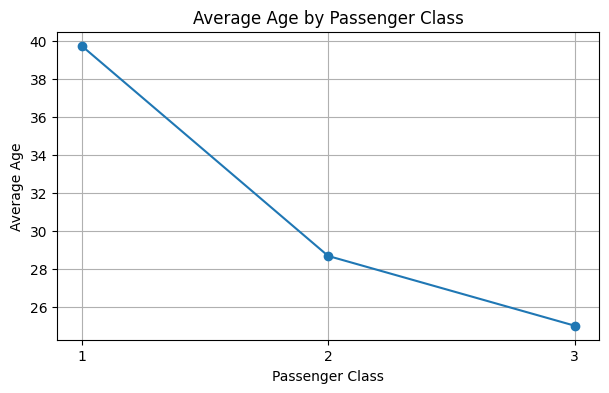

In [15]:
age_by_class = df.groupby("Pclass")["Age"].mean()

plt.figure(figsize=(7, 4))
plt.plot(age_by_class.index, age_by_class.values, marker="o")
plt.title("Average Age by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Age")
plt.xticks(age_by_class.index)
plt.grid(True)
plt.show()

## 4. Bar Chart

Use a bar chart to compare categories.

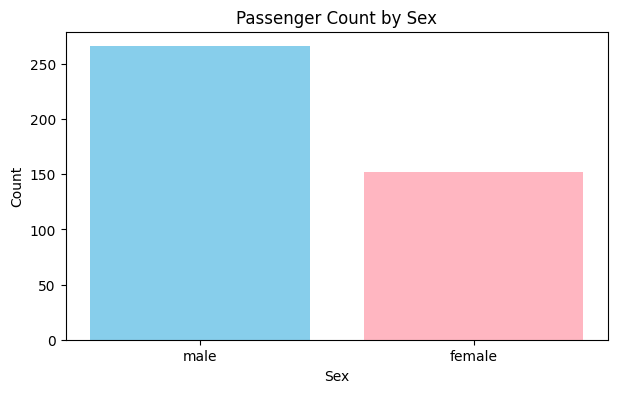

In [16]:
sex_count = df["Sex"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(sex_count.index, sex_count.values, color=["skyblue", "lightpink"])
plt.title("Passenger Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

## 5. Horizontal Bar Chart

Use a horizontal bar chart when category names are long or easy side comparison is needed.

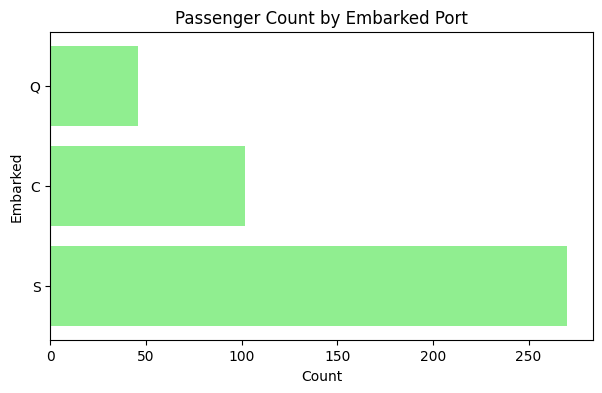

In [17]:
embarked_count = df["Embarked"].value_counts()

plt.figure(figsize=(7, 4))
plt.barh(embarked_count.index, embarked_count.values, color="lightgreen")
plt.title("Passenger Count by Embarked Port")
plt.xlabel("Count")
plt.ylabel("Embarked")
plt.show()

## 6. Grouped Bar Chart

Use a grouped bar chart to compare two or more groups side by side.

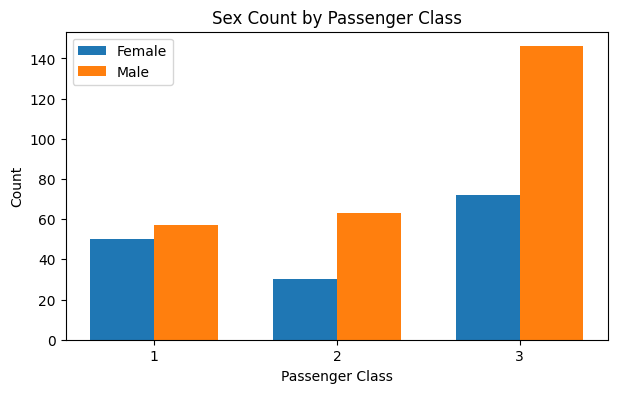

In [18]:
group_data = pd.crosstab(df["Pclass"], df["Sex"])
x = np.arange(len(group_data.index))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, group_data["female"], width, label="Female")
plt.bar(x + width/2, group_data["male"], width, label="Male")
plt.title("Sex Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.xticks(x, group_data.index)
plt.legend()
plt.show()

## 7. Stacked Bar Chart

Use a stacked bar chart to show total plus parts of each category.

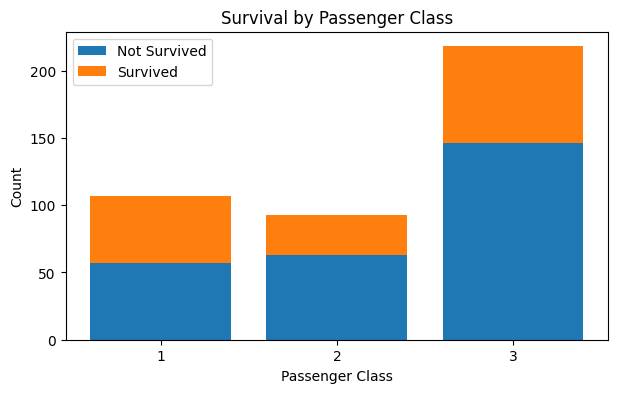

In [19]:
survival_class = pd.crosstab(df["Pclass"], df["Survived"])

plt.figure(figsize=(7, 4))
plt.bar(survival_class.index, survival_class[0], label="Not Survived")
plt.bar(survival_class.index, survival_class[1], bottom=survival_class[0], label="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.xticks(survival_class.index)
plt.legend()
plt.show()

## 8. Pie Chart

Use a pie chart to show percentage share. Use it only for a small number of categories.

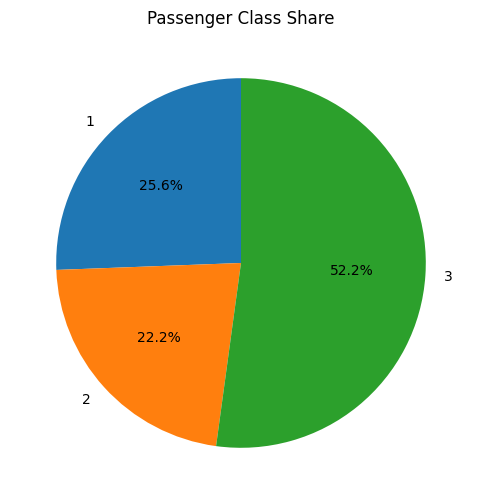

In [20]:
class_count = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(class_count.values, labels=class_count.index, autopct="%1.1f%%", startangle=90)
plt.title("Passenger Class Share")
plt.show()

## 9. Histogram

Use a histogram to see the distribution of one numeric column.

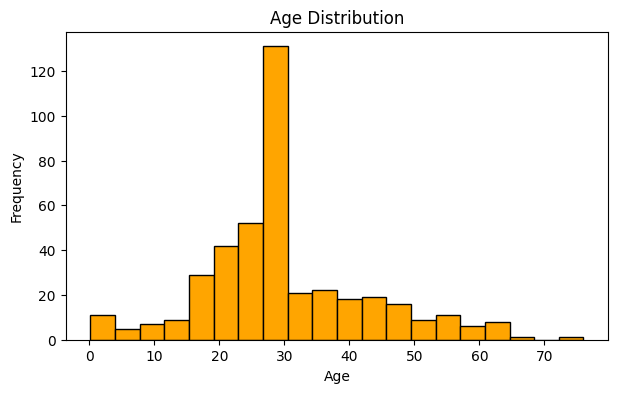

In [21]:
plt.figure(figsize=(7, 4))
plt.hist(df["Age"].dropna(), bins=20, color="orange", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 10. Box Plot

Use a box plot to find spread, median, and outliers.

C:\Users\RUPESH\AppData\Local\Temp\ipykernel_12512\2017538223.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(fare_by_class, labels=sorted(df["Pclass"].unique()))


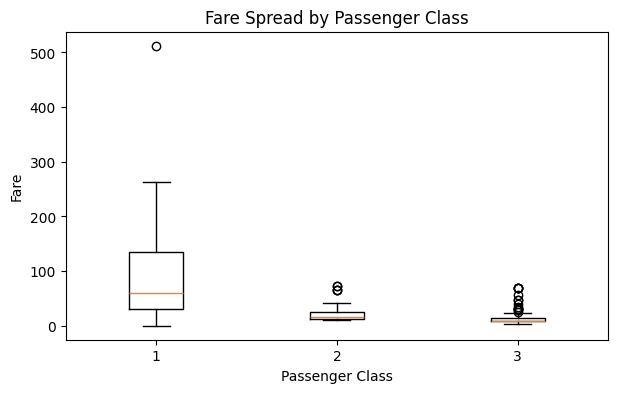

In [22]:
fare_by_class = [df[df["Pclass"] == c]["Fare"].dropna() for c in sorted(df["Pclass"].unique())]

plt.figure(figsize=(7, 4))
plt.boxplot(fare_by_class, labels=sorted(df["Pclass"].unique()))
plt.title("Fare Spread by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

## 11. Scatter Plot

Use a scatter plot to check relation between two numeric columns.

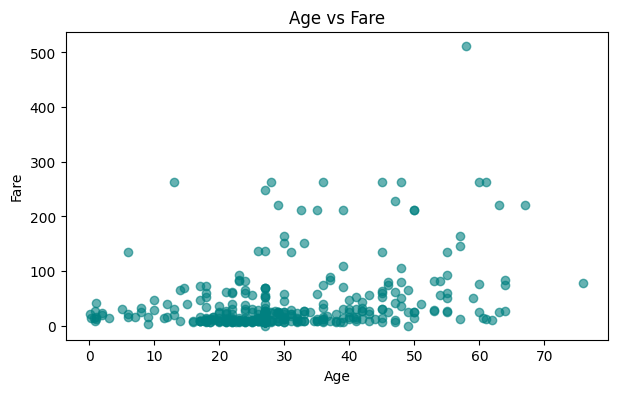

In [23]:
plt.figure(figsize=(7, 4))
plt.scatter(df["Age"], df["Fare"], alpha=0.6, color="teal")
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## 12. Area Chart

Use an area chart to show volume or filled trend.

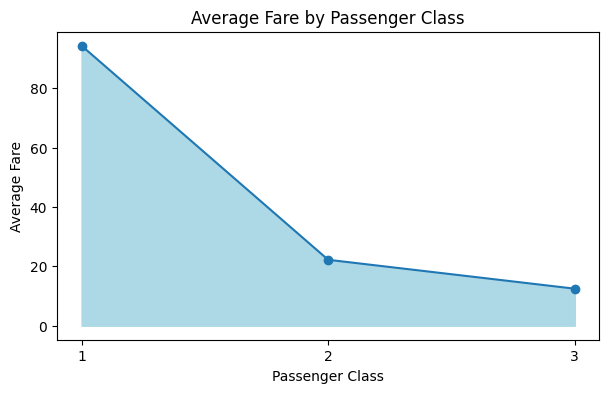

In [24]:
fare_by_class = df.groupby("Pclass")["Fare"].mean()

plt.figure(figsize=(7, 4))
plt.fill_between(fare_by_class.index, fare_by_class.values, color="lightblue")
plt.plot(fare_by_class.index, fare_by_class.values, marker="o")
plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.xticks(fare_by_class.index)
plt.show()

## 13. Step Chart

Use a step chart when values change in steps, like levels or stages.

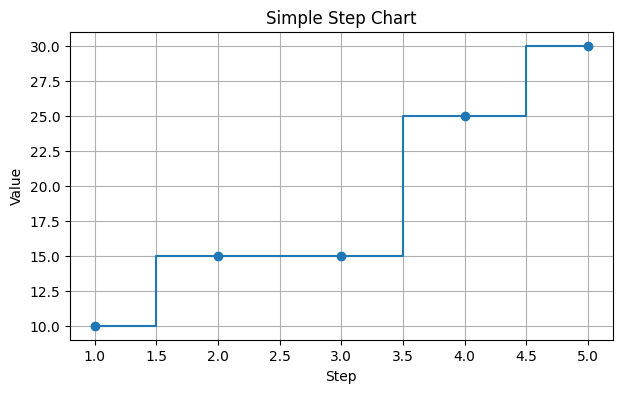

In [25]:
x = [1, 2, 3, 4, 5]
y = [10, 15, 15, 25, 30]

plt.figure(figsize=(7, 4))
plt.step(x, y, where="mid", marker="o")
plt.title("Simple Step Chart")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## 14. Stem Plot

Use a stem plot for small discrete numeric values.

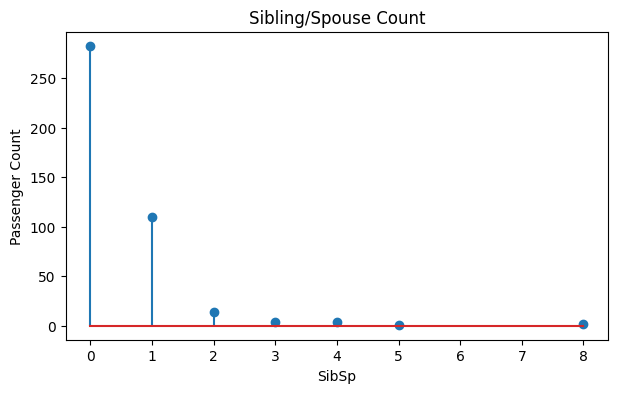

In [26]:
siblings_count = df["SibSp"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.stem(siblings_count.index, siblings_count.values)
plt.title("Sibling/Spouse Count")
plt.xlabel("SibSp")
plt.ylabel("Passenger Count")
plt.show()

## 15. Error Bar Chart

Use an error bar chart to show average value with variation.

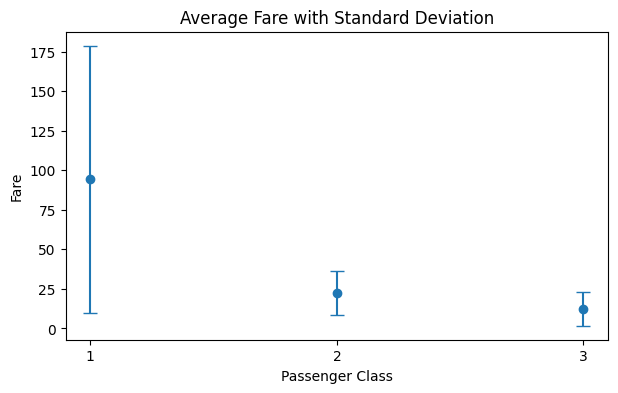

In [27]:
fare_mean = df.groupby("Pclass")["Fare"].mean()
fare_std = df.groupby("Pclass")["Fare"].std()

plt.figure(figsize=(7, 4))
plt.errorbar(fare_mean.index, fare_mean.values, yerr=fare_std.values, fmt="o", capsize=5)
plt.title("Average Fare with Standard Deviation")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.xticks(fare_mean.index)
plt.show()

## 16. Heatmap using Matplotlib

Use a heatmap to show values in a matrix. Here we use `imshow`.

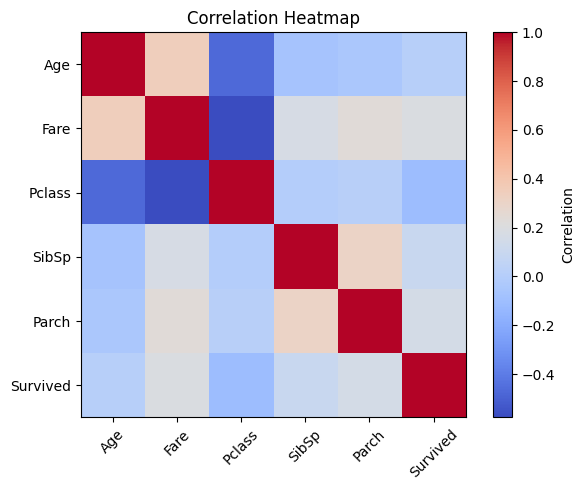

In [28]:
numeric_df = df[["Age", "Fare", "Pclass", "SibSp", "Parch", "Survived"]]
corr = numeric_df.corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

## 17. Subplots

Use subplots to show multiple charts in one figure.

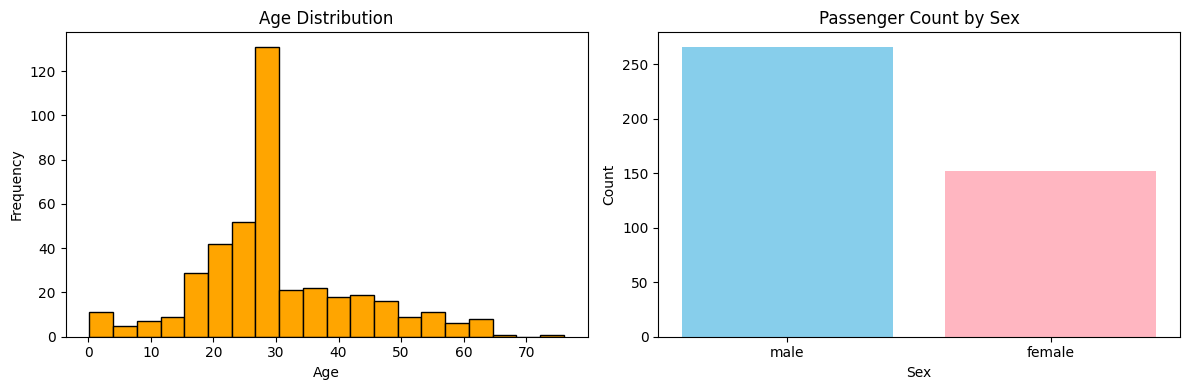

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Age"].dropna(), bins=20, color="orange", edgecolor="black")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

axes[1].bar(sex_count.index, sex_count.values, color=["skyblue", "lightpink"])
axes[1].set_title("Passenger Count by Sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 18. Contour Plot

Use a contour plot for 3D-like data shown on a 2D plane.

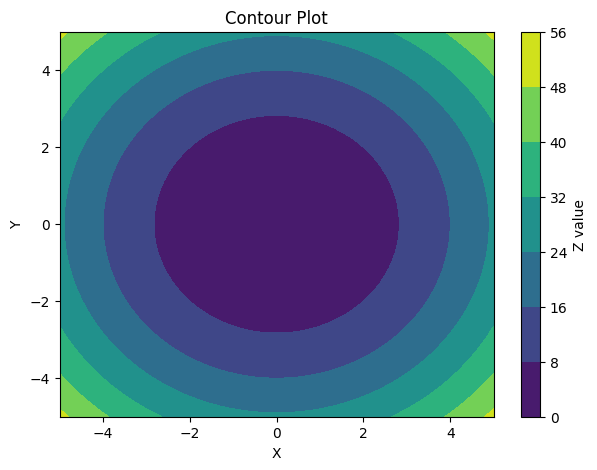

In [30]:
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

plt.figure(figsize=(7, 5))
plt.contourf(X, Y, Z, cmap="viridis")
plt.colorbar(label="Z value")
plt.title("Contour Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## 19. 3D Scatter Plot

Use a 3D scatter plot when you want to compare three numeric columns.

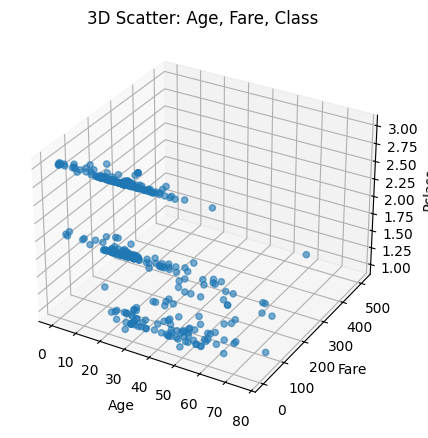

In [31]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df["Age"], df["Fare"], df["Pclass"], alpha=0.6)
ax.set_title("3D Scatter: Age, Fare, Class")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")
ax.set_zlabel("Pclass")
plt.show()

## 20. 3D Surface Plot

Use a surface plot to show a smooth 3D surface.

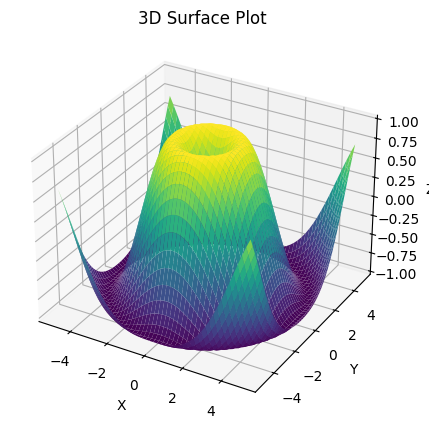

In [32]:
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis")
ax.set_title("3D Surface Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

## 21. Quick Revision Table

| Chart | Function | Best Use |
 |---|---|---|
 | Line | `plt.plot()` | Trend or change |
 | Bar | `plt.bar()` | Category comparison |
 | Horizontal Bar | `plt.barh()` | Category comparison with long labels |
 | Grouped Bar | `plt.bar()` with shifted x | Side-by-side comparison |
 | Stacked Bar | `plt.bar(..., bottom=...)` | Total and parts |
 | Pie | `plt.pie()` | Percentage share |
 | Histogram | `plt.hist()` | Numeric distribution |
 | Box Plot | `plt.boxplot()` | Spread and outliers |
 | Scatter | `plt.scatter()` | Relation between two numbers |
 | Area | `plt.fill_between()` | Filled trend |
 | Step | `plt.step()` | Step-wise change |
 | Stem | `plt.stem()` | Discrete numeric values |
 | Error Bar | `plt.errorbar()` | Average with variation |
 | Heatmap | `plt.imshow()` | Matrix values |
 | Subplots | `plt.subplots()` | Multiple charts together |
 | Contour | `plt.contourf()` | 3D-like data in 2D |
 | 3D Scatter | `ax.scatter(..., projection='3d')` | Three numeric variables |
 | 3D Surface | `ax.plot_surface()` | Smooth 3D surface |